In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pprint import pprint 
from itertools import product
import json
import statsmodels
import collections
from datetime import datetime
from tqdm import tqdm

from darts import TimeSeries, concatenate
from darts.models import AutoARIMA, ExponentialSmoothing, AutoTBATS, TBATS, Theta, FourTheta, Prophet, FFT, KalmanForecaster, Croston, RandomForest, LinearRegressionModel, LightGBMModel, CatBoostModel, RNNModel
from darts.metrics import mae
from darts.dataprocessing.transformers import MinTReconciliator, MissingValuesFiller


/Users/eldi/Documents/Projects/Hierarchical-Time-Series/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
horizon = 6

In [3]:
df_train = pd.read_csv('../../data/processed/hierarchy_train.csv')
df_test = pd.read_csv('../../data/processed/hierarchy_test.csv')

In [6]:
df = pd.concat([df_train, df_test], ignore_index=True)

In [7]:
df.Date = pd.to_datetime(df.Date)


In [8]:
with open('../../src/utils/hierarchy_dict.json', 'r') as f:
    hier = json.load(f)

In [9]:
df.set_index('Date', inplace=True)
df = df.sort_index()

In [10]:
hier = {i:[k for k in j if k in df.columns] for i,j in hier.items()}

In [11]:
hier_darts = {k:[i] for i,j in hier.items() for k in j}

In [12]:
df = df.resample('ME').mean()


In [13]:
df_darts = TimeSeries.from_dataframe(df, freq='ME', hierarchy = hier_darts)

In [14]:
def smape(actu, pred):
    return ((2*abs(pred-actu)/(abs(pred)+abs(actu)))).sum()/len(actu)*100

In [22]:
def test_all_models(dataset):
    dataset = df_darts[dataset]
    dataset = dataset.astype(np.float32)
    preds = {}
    models = [
        AutoARIMA, ExponentialSmoothing, AutoTBATS, TBATS, Prophet, FFT, KalmanForecaster, Croston, RandomForest, LinearRegressionModel,
        LightGBMModel, CatBoostModel, RNNModel
              ]
    for model in models:
        if model.__name__ in ("RandomForest", "LinearRegressionModel", "LightGBMModel", "CatBoostModel"):
            m = model(lags=12)
        elif model.__name__ == "RNNModel":
            m = model(input_chunk_length = 12)
        elif "TBATS" in model.__name__:
            m = model(season_length=12)
        else:
            m = model()
        pp = []
        for i in range(horizon-1, 0, -1):
            m.fit(dataset[:-i])
            pp.append(m.predict(n=1).to_dataframe()[dataset.components[0]])
        preds[model.__name__] = pd.concat(pp)
    comparison = pd.DataFrame(preds)
    errors = comparison.apply(lambda x: smape(x, dataset[-horizon+1:].to_series()))
    return {
        'component':dataset.components[0],
        'model':errors.idxmin(),
        'error':errors.min(),
        'pred':comparison[errors.idxmin()]
    }, comparison

In [23]:
import logging
logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)
logging.getLogger("darts").setLevel(logging.ERROR)

In [24]:
from warnings import filterwarnings
filterwarnings('ignore')

In [26]:
foo = list(map(test_all_models, tqdm([j for i in hier['total'] for j in hier[i]]+hier['total'])))

  0%|          | 0/51 [00:00<?, ?it/s]20:20:29 - cmdstanpy - INFO - Chain [1] start processing
20:20:30 - cmdstanpy - INFO - Chain [1] done processing
20:20:30 - cmdstanpy - INFO - Chain [1] start processing
20:20:30 - cmdstanpy - INFO - Chain [1] done processing
20:20:30 - cmdstanpy - INFO - Chain [1] start processing
20:20:30 - cmdstanpy - INFO - Chain [1] done processing
20:20:30 - cmdstanpy - INFO - Chain [1] start processing
20:20:30 - cmdstanpy - INFO - Chain [1] done processing
20:20:30 - cmdstanpy - INFO - Chain [1] start processing
20:20:30 - cmdstanpy - INFO - Chain [1] done processing


[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 36, number of used features: 0
[LightGBM] [Info] Start training from score 1551.972639
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the s

  2%|▏         | 1/51 [00:14<12:16, 14.72s/it]

20:20:42 - cmdstanpy - INFO - Chain [1] start processing
20:20:42 - cmdstanpy - INFO - Chain [1] done processing
20:20:42 - cmdstanpy - INFO - Chain [1] start processing
20:20:42 - cmdstanpy - INFO - Chain [1] done processing
20:20:42 - cmdstanpy - INFO - Chain [1] start processing
20:20:42 - cmdstanpy - INFO - Chain [1] done processing
20:20:42 - cmdstanpy - INFO - Chain [1] start processing
20:20:42 - cmdstanpy - INFO - Chain [1] done processing
20:20:42 - cmdstanpy - INFO - Chain [1] start processing
20:20:43 - cmdstanpy - INFO - Chain [1] done processing


[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 36, number of used features: 0
[LightGBM] [Info] Start training from score 2416.231132
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the s

...

20:30:16 - cmdstanpy - INFO - Chain [1] start processing
20:30:16 - cmdstanpy - INFO - Chain [1] done processing
20:30:16 - cmdstanpy - INFO - Chain [1] start processing
20:30:16 - cmdstanpy - INFO - Chain [1] done processing
20:30:16 - cmdstanpy - INFO - Chain [1] start processing
20:30:16 - cmdstanpy - INFO - Chain [1] done processing
20:30:16 - cmdstanpy - INFO - Chain [1] start processing
20:30:16 - cmdstanpy - INFO - Chain [1] done processing
20:30:16 - cmdstanpy - INFO - Chain [1] start processing
20:30:16 - cmdstanpy - INFO - Chain [1] done processing


[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 36, number of used features: 0
[LightGBM] [Info] Start training from score 24907.821018
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the 

 98%|█████████▊| 50/51 [09:59<00:11, 11.85s/it]20:30:28 - cmdstanpy - INFO - Chain [1] start processing
20:30:28 - cmdstanpy - INFO - Chain [1] done processing
20:30:28 - cmdstanpy - INFO - Chain [1] start processing
20:30:28 - cmdstanpy - INFO - Chain [1] done processing
20:30:28 - cmdstanpy - INFO - Chain [1] start processing
20:30:28 - cmdstanpy - INFO - Chain [1] done processing
20:30:28 - cmdstanpy - INFO - Chain [1] start processing
20:30:28 - cmdstanpy - INFO - Chain [1] done processing
20:30:28 - cmdstanpy - INFO - Chain [1] start processing
20:30:28 - cmdstanpy - INFO - Chain [1] done processing


[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 36, number of used features: 0
[LightGBM] [Info] Start training from score 35541.083279
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the 

100%|██████████| 51/51 [10:11<00:00, 11.99s/it]


In [33]:
test_total_level = test_all_models('total')

20:33:50 - cmdstanpy - INFO - Chain [1] start processing
20:33:50 - cmdstanpy - INFO - Chain [1] done processing
20:33:50 - cmdstanpy - INFO - Chain [1] start processing
20:33:50 - cmdstanpy - INFO - Chain [1] done processing
20:33:50 - cmdstanpy - INFO - Chain [1] start processing
20:33:50 - cmdstanpy - INFO - Chain [1] done processing
20:33:50 - cmdstanpy - INFO - Chain [1] start processing
20:33:50 - cmdstanpy - INFO - Chain [1] done processing
20:33:50 - cmdstanpy - INFO - Chain [1] start processing
20:33:50 - cmdstanpy - INFO - Chain [1] done processing


[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 36, number of used features: 0
[LightGBM] [Info] Start training from score 143583.039714
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the

<Axes: xlabel='Date'>

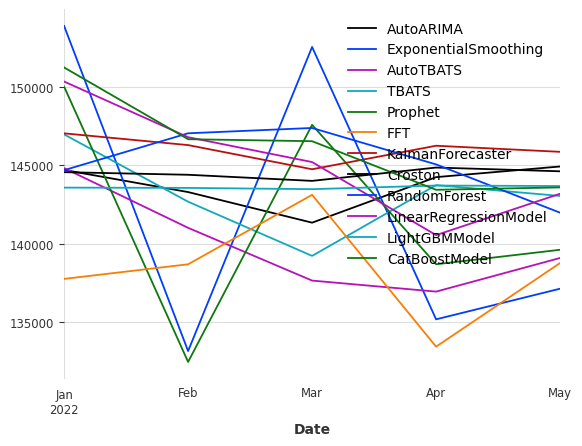

In [35]:
test_total_level[1].drop(columns='RNNModel').plot()

<Axes: xlabel='Date'>

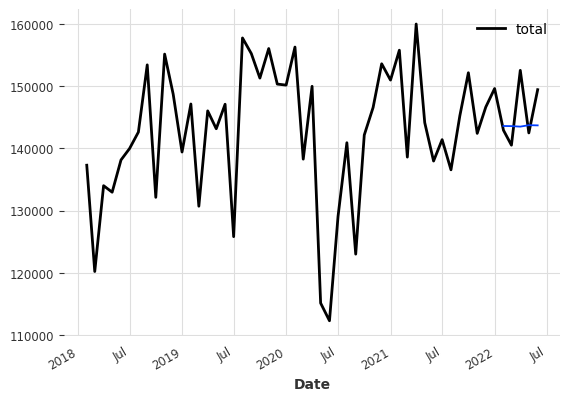

In [44]:
df_darts['total'].plot()
test_total_level[0]['pred'].plot()


In [48]:
selected_models = dict(map(lambda x: (x[0]['component'], x[0]['model']), foo))

In [50]:
selected_models_v3 = {k:selected_models[i] for i,j in hier.items() if i in selected_models.keys() for k in j}

In [52]:
selected_models.update(selected_models_v3)

In [53]:
selected_models.update({'total':test_total_level[0]['model']})

In [55]:
with open('../../src/utils/selected_models.json', 'w') as f:
    json.dump(selected_models, f)

In [59]:
pd.Series(selected_models).value_counts()

LinearRegressionModel    128
RandomForest             101
Prophet                   80
ExponentialSmoothing      77
LightGBMModel             67
AutoARIMA                 40
Croston                   39
KalmanForecaster          23
FFT                       13
CatBoostModel              6
TBATS                      2
AutoTBATS                  1
Name: count, dtype: int64

In [85]:
models_h = []

models = {
    'AutoARIMA':AutoARIMA,
    'ExponentialSmoothing':ExponentialSmoothing,
    'AutoTBATS':AutoTBATS, 
    'TBATS':TBATS,
    'Prophet':Prophet, 
    'FFT':FFT,
    'KalmanForecaster':KalmanForecaster, 
    'Croston':Croston, 
    'RandomForest':RandomForest, 
    'LinearRegressionModel':LinearRegressionModel,
    'LightGBMModel':LightGBMModel, 
    'CatBoostModel':CatBoostModel, 
    'RNNModel':RNNModel
}

for i in tqdm(df_darts.components):
    pp = []
    dataset = df_darts[i]
    model = models[selected_models[i]]
    if model.__name__ in ("RandomForest", "LinearRegressionModel", "LightGBMModel", "CatBoostModel"):
        m = model(lags=12)
    elif model.__name__ == "RNNModel":
        m = model(input_chunk_length = 12)
    elif "TBATS" in model.__name__:
        m = model(season_length=12)
    else:
        m = model()
    
    for i in range(horizon-1, 0, -1):
        m.fit(dataset[:-i])
        pp.append(m.predict(n=1).to_dataframe()[dataset.components[0]])
    comparison = pd.concat(pp).to_frame()
    #errors = comparison.apply(lambda x: smape(x, dataset[-horizon+1:].to_series()))
    models_h.append(comparison)

  0%|          | 0/577 [00:00<?, ?it/s]21:40:37 - cmdstanpy - INFO - Chain [1] start processing
21:40:37 - cmdstanpy - INFO - Chain [1] done processing
21:40:37 - cmdstanpy - INFO - Chain [1] start processing
21:40:38 - cmdstanpy - INFO - Chain [1] done processing
21:40:38 - cmdstanpy - INFO - Chain [1] start processing
21:40:38 - cmdstanpy - INFO - Chain [1] done processing
21:40:38 - cmdstanpy - INFO - Chain [1] start processing
21:40:38 - cmdstanpy - INFO - Chain [1] done processing
21:40:38 - cmdstanpy - INFO - Chain [1] start processing
21:40:38 - cmdstanpy - INFO - Chain [1] done processing
  0%|          | 1/577 [00:00<04:53,  1.96it/s]21:40:38 - cmdstanpy - INFO - Chain [1] start processing
21:40:38 - cmdstanpy - INFO - Chain [1] done processing
21:40:38 - cmdstanpy - INFO - Chain [1] start processing
21:40:38 - cmdstanpy - INFO - Chain [1] done processing
21:40:38 - cmdstanpy - INFO - Chain [1] start processing
21:40:38 - cmdstanpy - INFO - Chain [1] done processing
21:40:38 -

[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 36, number of used features: 0
[LightGBM] [Info] Start training from score 16.153334
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the spl

21:40:41 - cmdstanpy - INFO - Chain [1] done processing
21:40:41 - cmdstanpy - INFO - Chain [1] start processing
21:40:41 - cmdstanpy - INFO - Chain [1] done processing
21:40:41 - cmdstanpy - INFO - Chain [1] start processing
21:40:41 - cmdstanpy - INFO - Chain [1] done processing
21:40:41 - cmdstanpy - INFO - Chain [1] start processing
21:40:41 - cmdstanpy - INFO - Chain [1] done processing
21:40:41 - cmdstanpy - INFO - Chain [1] start processing
21:40:41 - cmdstanpy - INFO - Chain [1] done processing
21:40:41 - cmdstanpy - INFO - Chain [1] start processing
21:40:41 - cmdstanpy - INFO - Chain [1] done processing
21:40:41 - cmdstanpy - INFO - Chain [1] start processing
21:40:41 - cmdstanpy - INFO - Chain [1] done processing
21:40:42 - cmdstanpy - INFO - Chain [1] start processing
21:40:42 - cmdstanpy - INFO - Chain [1] done processing
21:40:42 - cmdstanpy - INFO - Chain [1] start processing
21:40:42 - cmdstanpy - INFO - Chain [1] done processing
  2%|▏         | 11/577 [00:04<03:08,  3

[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 36, number of used features: 0
[LightGBM] [Info] Start training from score 384.721668
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the sp

21:40:44 - cmdstanpy - INFO - Chain [1] start processing
21:40:44 - cmdstanpy - INFO - Chain [1] done processing
21:40:44 - cmdstanpy - INFO - Chain [1] start processing
21:40:44 - cmdstanpy - INFO - Chain [1] done processing
21:40:44 - cmdstanpy - INFO - Chain [1] start processing
21:40:44 - cmdstanpy - INFO - Chain [1] done processing
21:40:44 - cmdstanpy - INFO - Chain [1] start processing
21:40:45 - cmdstanpy - INFO - Chain [1] done processing
  3%|▎         | 18/577 [00:07<03:15,  2.86it/s]21:40:45 - cmdstanpy - INFO - Chain [1] start processing
21:40:45 - cmdstanpy - INFO - Chain [1] done processing
21:40:45 - cmdstanpy - INFO - Chain [1] start processing
21:40:45 - cmdstanpy - INFO - Chain [1] done processing
21:40:45 - cmdstanpy - INFO - Chain [1] start processing
21:40:45 - cmdstanpy - INFO - Chain [1] done processing
21:40:45 - cmdstanpy - INFO - Chain [1] start processing
21:40:45 - cmdstanpy - INFO - Chain [1] done processing
21:40:45 - cmdstanpy - INFO - Chain [1] start pr

...

[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more 

 99%|█████████▉| 574/577 [01:34<00:00, 10.08it/s]

[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 36, number of used features: 0
[LightGBM] [Info] Start training from score 24260.557265
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the 

100%|██████████| 577/577 [01:34<00:00,  6.08it/s]

[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 36, number of used features: 0
[LightGBM] [Info] Start training from score 143583.039714
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the

In [86]:
opti_pred = pd.concat(models_h, axis=1)

<Axes: xlabel='Date'>

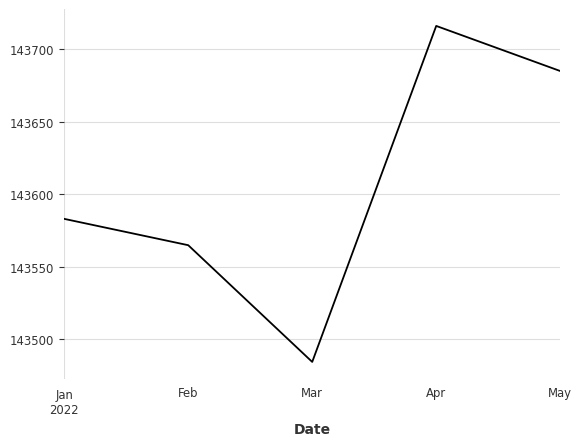

In [87]:
opti_pred['total'].plot()

In [88]:
errors = opti_pred.apply(lambda x: smape(df_darts[x.name][-horizon+1:].to_series(),x))

In [100]:
errors.total

np.float64(2.701240073479986)

In [93]:
from darts import TimeSeries, concatenate

In [94]:
opti_pred_h = TimeSeries.from_dataframe(opti_pred, freq='M', hierarchy=hier_darts)

# Ensure that all above is retrained using the train dataset only. Then below reconcile on it and then transform the test dataset

# Additionally review the prediction horizon and the method of reconciliation

In [96]:
reconciliator = MinTReconciliator(method='wls_struct')
reconciliator.fit(df_darts[:-horizon])
reconciliator_preds = reconciliator.transform(opti_pred_h)

In [97]:
reconciliator_smape = reconciliator_preds.to_dataframe().apply(lambda x: smape(df_darts[x.name][-horizon+1:].to_series(), x))

In [ ]:
reconciliator_smape

component
A_0_4      26.123685
A_0_7     200.000000
A_0_8     166.086942
A_0_16    161.516396
A_1_29     20.291602
             ...    
C           3.588826
D           5.276667
E           3.524282
F           3.966870
total       2.773213
Length: 577, dtype: float64

<Axes: >

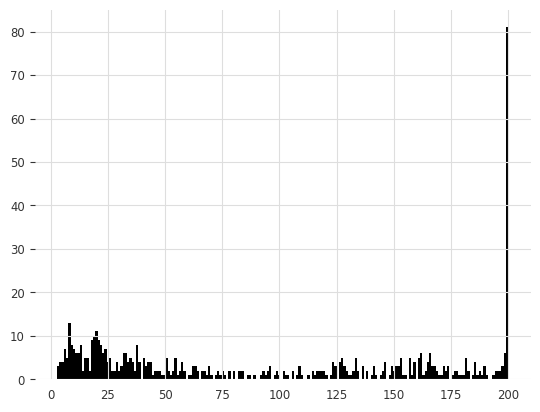

In [101]:
reconciliator_smape.hist(bins=200)

In [102]:
def ree(i):
    print(reconciliator_smape[i])
    print(selected_models[i])
    df_darts[i].plot()
    opti_pred[i].plot()
    reconciliator_preds[i].plot()
    plt.show()

2.773212529634499
LightGBMModel


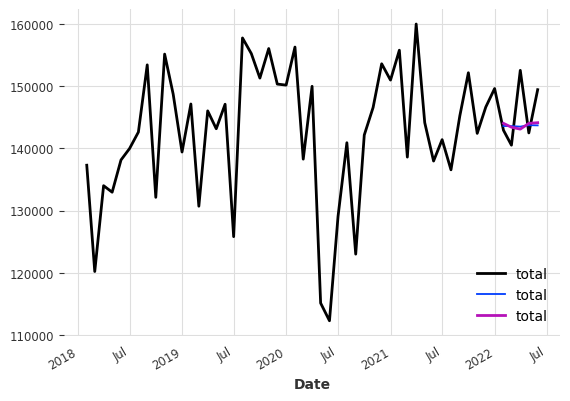

In [103]:
ree('total')

4.232421994981116
LinearRegressionModel


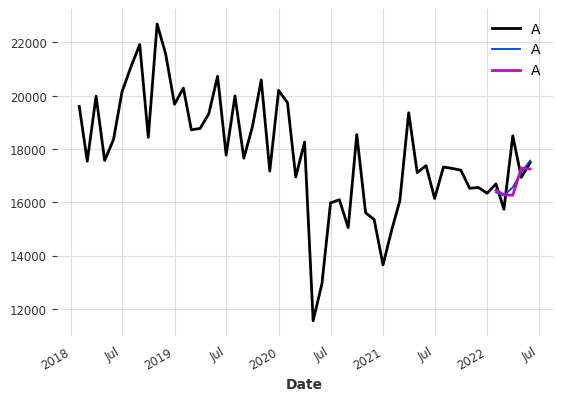

3.5888258216832787
FFT


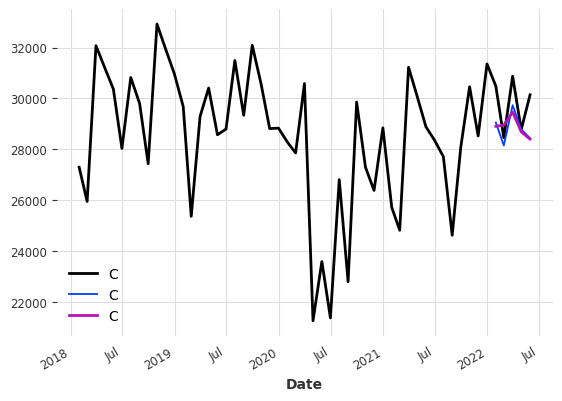

3.966869840298428
KalmanForecaster


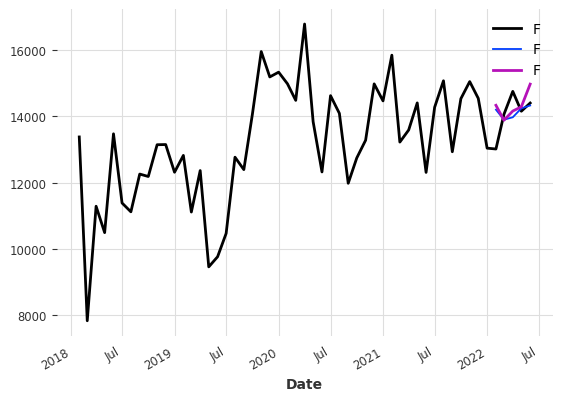

5.276666789279711
LightGBMModel


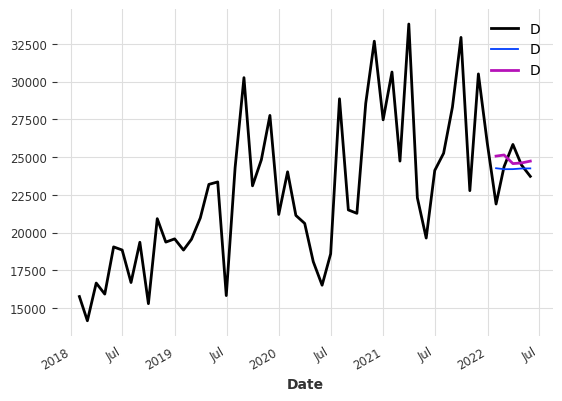

5.7100441574566485
KalmanForecaster


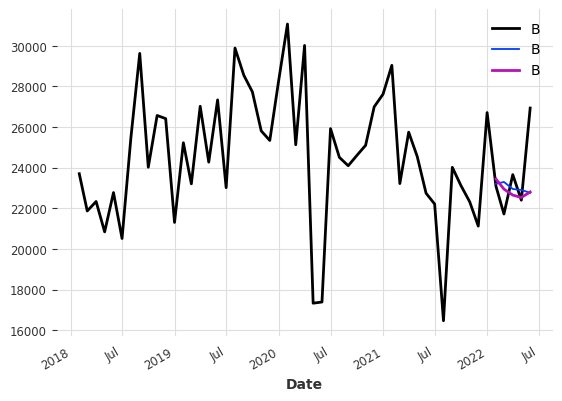

3.5242823424285543
AutoARIMA


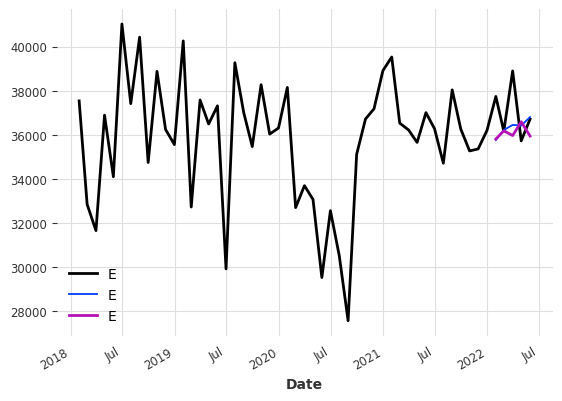

In [104]:
for i in hier['total']:
    ree(i)

In [105]:
reconciliator_smape.sort_values()

component
total         2.773213
E             3.524282
C             3.588826
B_1           3.865783
B_1_215       3.865783
               ...    
F_0_403     200.000000
B_0_295     200.000000
D_5_1042    200.000000
D_5_995     200.000000
D_5_425     200.000000
Length: 577, dtype: float64

In [115]:
stdss = df.groupby(df.index.year).mean().std()

<Axes: >

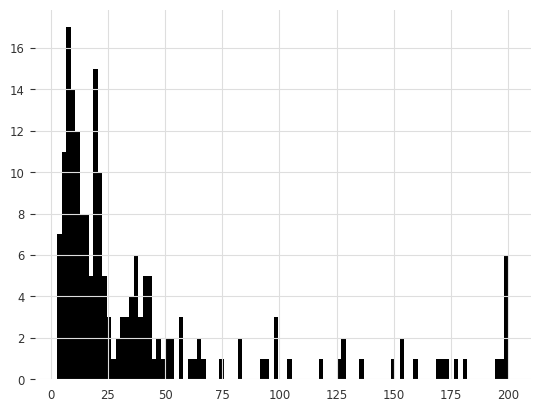

In [119]:
reconciliator_smape[stdss[stdss>50].index].hist(bins=100)

In [122]:
reconciliator_smape[stdss[stdss>50].index].sort_values().tail(20)

F_6_323     127.543204
F_6_461     127.637999
F_5_494     136.358132
E_7_1026    149.641491
B_0_254     153.163884
F_0_401     153.482926
B_0_192     159.374319
B_6_265     169.754792
E_0_1065    171.189370
A_3_32      174.223090
E_7_1002    177.081488
C_5_369     181.450801
B_6_631     194.460442
B_6_729     197.394939
E_7_759     198.905465
D_2         200.000000
B_0_236     200.000000
B_6_902     200.000000
D_2_961     200.000000
E_0_236     200.000000
dtype: float64

11.272557716007341
LightGBMModel


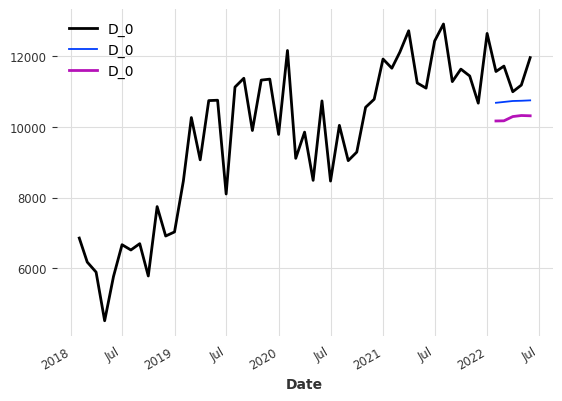

In [130]:
ree('D_0')